# Imports

In [1]:
import os
import sys

In [2]:
current_dir =  os.getcwd()
# replace this following line in the path your frank2d files are.
parent_dir = os.path.abspath(os.path.join(current_dir, os.pardir))
sys.path.append(parent_dir)

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import time

In [4]:
# frank2d
from frank2d import Frank2D
from frank2d.geometry import Geometry
from frank2d.posterior_optimization import *
from frank2d.constants import rad_to_arcsec, deg_to_rad
from frank2d.plot import Plot

# frank1d
from frank.utilities import UVDataBinner

In [5]:
# frank1d
import frank
from frank.geometry import  SourceGeometry
from frank.radial_fitters import FrankFitter
from frank.utilities import UVDataBinner

## Functions

In [6]:
def run_plot(binning, x_lims = (1e5,8e6), y_lims_re = (-11, 17), y_lims_im = (-2, 2)):
    # Errors of visibilities
    binning = binning
    binning_re = binning.V.real*1e3
    binning_im = binning.V.imag*1e3
    binning_uv = binning.uv
    binning_re_err = binning.error.real*1e3
    binning_im_err = binning.error.imag*1e3

    x_lims = x_lims
    y_lims_re = y_lims_re
    y_lims_im = y_lims_im

    target_label = disk_name

    #Plot data
    fig, axs = plt.subplots(2,1,figsize=(12,5), gridspec_kw={'height_ratios': [3, 1]})
    plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0, hspace=0.05)

    #axs[0].plot(binned_vis0.uv, binned_vis0.V.real*1e3, c=cs[0], marker=ms[0], ls='None', alpha=0.5,
    #                label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[0]/1e3))
    axs[0].errorbar(binning_uv, binning_re, binning_re_err, color='gray',fmt='x', alpha=0.7, capsize=2, linewidth=1, zorder=1, label='Data')
    #axs[0].plot(binning_uv / 1e6, vis_fit, color='r', linewidth=2, zorder=1.5, label='frank fit')
    axs[0].text(0.96, 0.88, target_label, ha='right', transform=axs[0].transAxes, fontsize=25)
    axs[0].plot(q, vis_model_1d_f2d.real*1e3, color = '#FA00FA', ls ='--', label = r'frank2d')
    axs[0].set_xscale('log')

    axs[1].errorbar(binning_uv, binning_im, binning_im_err, color='grey', fmt='x', alpha=0.7, capsize=2, linewidth=1, zorder=1)
    axs[1].plot(binning_uv, np.zeros(binning_uv.shape[0]), color='r', linestyle='dashed', zorder=1.5, linewidth=2)
    axs[1].plot(q, vis_model_1d_f2d.imag*1e3, color = '#FA00FA', ls ='--', label = r'frank2d')
    axs[1].set_xscale('log')

    axs[0].hlines(0,-10,10, alpha=1, linestyle=(0,(1,5)), color='k', linewidth=1, zorder=0)
    axs[1].hlines(0,-10,10, alpha=1, linestyle=(0,(1,5)), color='k', linewidth=1, zorder=0)


    axs[0].set_xlim(x_lims)
    axs[1].set_xlim(x_lims)
    axs[0].set_ylim(y_lims_re)
    axs[1].set_ylim(y_lims_im)

    axs[0].tick_params(which='major',axis='both',right=True,top=True, labelsize=15, pad=10,width=2.5, length=5,direction='in',color='k')
    axs[0].tick_params(which='minor',axis='both',right=True,top=True, labelsize=15, pad=10,width=1.5, length=3,direction='in',color='k')

    axs[1].tick_params(which='major',axis='both',right=True,top=True, labelsize=15, pad=10,width=2.5, length=5,direction='in',color='k')
    axs[1].tick_params(which='minor',axis='both',right=True,top=True, labelsize=15, pad=10,width=1.5, length=3,direction='in',color='k')

    axs[0].set_xlabel(r'Deprojected baseline (M$\lambda$)', fontsize = 15, labelpad=10)
    axs[0].set_ylabel('Re(V) (mJy)', fontsize = 15, labelpad=10)

    axs[1].set_xlabel(r'Deprojected baseline (M$\lambda$)', fontsize = 15, labelpad=10)
    axs[1].set_ylabel('Im(V) (mJy)', fontsize = 15, labelpad=15)

    handles, labels = axs[0].get_legend_handles_labels()
    order = [1, 0]  # frank fit second (index 0), Data first (index 1)
    axs[0].legend([handles[idx] for idx in order],[labels[idx] for idx in order],
                bbox_to_anchor=[0.98, 0.9], fontsize=12)

    # Hide x labels and tick labels for top plots and y ticks for right plots.
    for ax in axs.flat:
        ax.label_outer()
    
    for axis in ['top', 'bottom', 'left', 'right']:
        axs[0].spines[axis].set_linewidth(2)    
        axs[1].spines[axis].set_linewidth(2) 

In [7]:
from matplotlib.ticker import FuncFormatter

def sci_notation(x, pos):
    s = f"{x:.0e}"
    mantissa, exp = s.split('e')
    exp = int(exp)
    return rf"{mantissa}×10$^{{{exp}}}$" 

def float_notation(x, pos):
    s = f"{x:.0f}"
    return s

In [8]:
def calculate_resolution( clean_beam, intrinsic_resolution):
    bmaj_as = clean_beam['bmaj']
    bmin_as = clean_beam['bmin']
    final_bmaj_as = np.sqrt(bmaj_as**2 - intrinsic_resolution**2)
    final_bmin_as = np.sqrt(bmin_as**2 - intrinsic_resolution**2)
    print(f"-> Final beam to convolve with: {final_bmaj_as} x {final_bmin_as} arcsec")
    final_resolution = {'bmaj': final_bmaj_as, 'bmin': final_bmin_as, 'beam_pa': clean_beam['beam_pa']}
    return final_resolution

In [9]:
def edges(x):
    mids = (x[1:] + x[:-1]) / 2.0
    first = x[0]  - (x[1] - x[0]) / 2.0
    last  = x[-1] + (x[-1] - x[-2]) / 2.0
    return np.r_[first, mids, last]


In [10]:
def get_profile( x1, x2, f, bins, weighted = False, weights = None, fit_1d = False):
    from scipy.stats import binned_statistic
    
    if not fit_1d:
        r = np.hypot(x1, x2)
        r = r.ravel(order = 'C')
        f = f.ravel(order = 'C')
    else:
        r = x1

    if weighted:
        if weights is None:
            raise ValueError("Add weights.")
        F_W_binned, bin_edges, _ = binned_statistic(r, f*weights, 'sum', bins = bins)
        Weights_binned, bin_edges, _ = binned_statistic(r, weights, 'sum', bins = bins)

        f_1d = np.nan_to_num(F_W_binned, nan=0)
        f_1d = f_1d/Weights_binned
    else:
        f_1d, bin_edges, _ = binned_statistic(r, f, 'mean', bins = bins)
    
    r_1d = (bin_edges[:-1] + bin_edges[1:]) / 2
        
    return r_1d, f_1d

## Load data

In [11]:
AS209 = {'inc': 34.97, 'pa': 85.76, 'dra':1.9e-3, 'ddec':-2.5e-3, 'rout': 1.2, 'disk_name': 'AS209'}


In [12]:
data = AS209

# UVtable
dir = "../../data/uvtable/"
disk_name = data['disk_name']
data_file = dir +"uvtable_" + disk_name + "_continuum.npz"

# Load data
file = np.load(data_file)
u, v, Re, Im, Weights = file['u'], file['v'], file['Re'], file['Im'], file['w']
Vis = Re + Im*1j

uvtable = {'u': u, 'v': v, 'vis': Vis, 'weights': Weights}

In [13]:
# Huang 2018 
inc = data['inc']
pa = data['pa']
dra = data['dra']
ddec = data['ddec']
rout = data['rout']

In [14]:
q_min = np.hypot(u,v).min()
q_max = np.hypot(u,v).max()
print(f"-> q_min data: {q_min}, q_max data: {q_max}")

-> q_min data: 11458.93439803405, q_max data: 8857254.46918468


In [15]:
import math

In [16]:
q = np.hypot(uvtable['u'], uvtable['v'])
q_min = np.min(q)
q_max = np.max(q)

Rmax = 3*rout
import math 
N = math.floor(5* Rmax/rad_to_arcsec * q_max)

print("N =", N)
print("Rmax =", Rmax)

N = 772
Rmax = 3.5999999999999996


In [17]:
Rmaxs = [Rmax]

In [18]:
import math
Ns = []
for i in Rmaxs:
    N = math.floor(5* Rmax/rad_to_arcsec * q_max)
    Ns.append(N)
    print(f"-> Suggested Ns values for Rmax = {i} au: {N}")

-> Suggested Ns values for Rmax = 3.5999999999999996 au: 772


In [19]:
frank_objects = []

In [20]:
for i in range(len(Rmaxs)):
    print(f"Rmax = {Rmaxs[i]} au, Ns = {Ns[i]}") 
    frank2d = Frank2D(Ns[i], Rmaxs[i])
    frank_objects.append(frank2d)

    Un = frank2d.FT.uv_points[0]
    Vn = frank2d.FT.uv_points[1]

    Qn = np.sort(np.hypot(Un, Vn))

    q_min_f2d = Qn[1]
    q_max_f2d = Qn[-1]
    print(f"-> q_min frank2d: {q_min_f2d}, q_max frank2d: {q_max_f2d}")
    print(f"-> q_min data: {q_min}, q_max data: {q_max}")

Rmax = 3.5999999999999996 au, Ns = 772
-> q_min frank2d: 28647.889756541164, q_max frank2d: 15638494.411648935
-> q_min data: 11458.93439803405, q_max data: 8857254.46918468


In [21]:
geom_f2d = Geometry(inc, pa, dra, ddec)

In [22]:
best_N50 = {'m': -2.2478888378636794, 'c': 241548327.67926273, 'l': 37853.96840857266}

## Frank2D

### run

In [23]:
for i in range(len(Rmaxs)):    
    start_time = time.time()
    frank_object = frank_objects[i]
    print(f"xxxxxxxxxxxxxxxxxxxxxxxxx F2D with N = {frank_object.Nx} and Rmax = {frank_object.Rmax} xxxxxxxxxxxxxxxxxxxxxxxxxxxx")
    frank_object.process_vis(uvtable)
    frank_object.fit(kernel_params = best_N50, rtol = 1e-10 )

    end_time = time.time()
    print(f"xxxxxxxxxxxxxxxxxxxxxxxxx F2D with N = {N} took {end_time - start_time} seconds xxxxxxxxxxxxxxxxxxxxxxxxxxxx")

xxxxxxxxxxxxxxxxxxxxxxxxx F2D with N = 772 and Rmax = 3.5999999999999996 xxxxxxxxxxxxxxxxxxxxxxxxxxxx


===>  Setting gridded data...
===>  Setting GP Kernel wend...
        + Kernel parameters:  {'m': -2.2478888378636794, 'c': 241548327.67926273, 'l': 37853.96840857266}
===>  Creating sparse linear system...
        +  Kernel = 0.05  min |  2.72 seconds
        +  Building system = 0.05  min |  2.79 seconds
===>  Solving linear system...


         + Fitting with BiCGStab...:   0%|          | 170/50000 [00:14<1:11:09, 11.67 iterations/s]


            +  BiCGStab = 0.24  min |  14.60 seconds
{'CGM_converged': True,
 'Fit_correctly': True,
 'convergence_by': 'norm of s',
 'final_tol': 0.021364751029161504,
 'iterations': 170,
 'maxiter': 50000,
 'preconditioner_method': 'jacobi',
 'rtol': 1e-10}
Building full visibility model...
     + Setting kernel..
--> time building S_12_T = 0.16  min |  9.42 seconds
--> times building full visibility model = 0.16  min |  9.46 seconds
xxxxxxxxxxxxxxxxxxxxxxxxx F2D with N = 772 took 37.6406044960022 seconds xxxxxxxxxxxxxxxxxxxxxxxxxxxx


In [24]:
#import pickle
#output_dir = "../../data/"
# save with pickle every frank2d object by its Rmax
#for i in frank_objects:
#    Rmax = i.Rmax
#    N = i.Nx
#    with open(output_dir + 'AS209_f2d_Rmax' + str(Rmax) +'_N'+ str(N) +'.pickle', 'wb') as f:
#        pickle.dump(i, f)

In [25]:
u_f2d = frank_objects[0].u_grid
v_f2d = frank_objects[0].v_grid

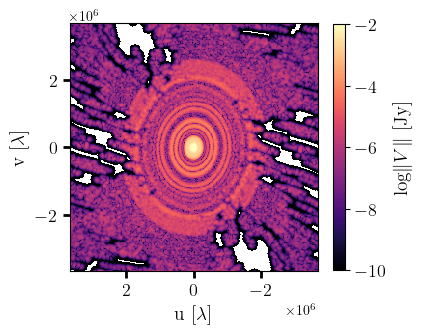

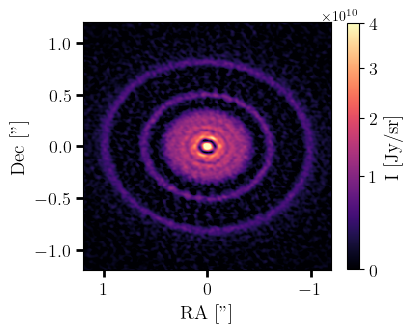

In [26]:
for i in frank_objects:
    Plot_ = Plot(i, geom_f2d)
    Plot_.visibility(
        kind='model',
        fig_size = 4,
        zoom =3, 
        title = r'',
        deproject = False)
    Plot_.intensity(fig_size = 4,
         title = r'',
         zoom =3, 
        gamma = 0.7)

## Frank1D

In [27]:
u_f1d, v_f1d =  uvtable['u'], uvtable['v']
vis_f1d = uvtable['vis']
weights_f1d = uvtable['weights']

In [28]:
# Frank 1D parameters
"""
n_pts = N//2
alpha = 1.2
w_smooth = 1e-2
r_out = Rmax

geom = SourceGeometry(inc= inc, PA= pa, dRA= dra, dDec= ddec)
FF = FrankFitter(r_out, n_pts, geom, alpha = alpha, weights_smooth = w_smooth)
sol = FF.fit(u_f1d, v_f1d, vis_f1d, weights_f1d)

#save object
import pickle
dir =  "../../data/uvtable/f1d/"
with open("f1d_AS209_N" + str(n_pts) + "_alpha" + str(alpha) + "_wsmooth" + str(w_smooth) + "_rout" + str(r_out) +".pickle", 'wb') as file:
    pickle.dump(sol, file)
"""

'\nn_pts = N//2\nalpha = 1.2\nw_smooth = 1e-2\nr_out = Rmax\n\ngeom = SourceGeometry(inc= inc, PA= pa, dRA= dra, dDec= ddec)\nFF = FrankFitter(r_out, n_pts, geom, alpha = alpha, weights_smooth = w_smooth)\nsol = FF.fit(u_f1d, v_f1d, vis_f1d, weights_f1d)\n\n#save object\nimport pickle\ndir =  "../../data/uvtable/f1d/"\nwith open("f1d_AS209_N" + str(n_pts) + "_alpha" + str(alpha) + "_wsmooth" + str(w_smooth) + "_rout" + str(r_out) +".pickle", \'wb\') as file:\n    pickle.dump(sol, file)\n'

In [29]:
import pickle
dir_f1d = "../../data/f1d/"
f1d_file = dir_f1d + "f1d_AS209_N386_alpha1.2_wsmooth0.01_rout3.5999999999999996.pickle"
with open(f1d_file, 'rb') as handle:
    sol = pickle.load(handle)

In [34]:
geom = SourceGeometry(inc= inc, PA= pa, dRA= dra, dDec= ddec)


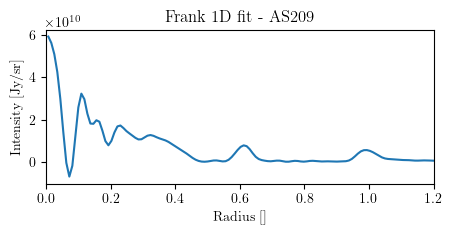

In [30]:
plt.figure(figsize=(5,2))
plt.title(f'Frank 1D fit - {disk_name}')
plt.plot(sol.r, sol.mean)
plt.xlim(0, Rmax/3)
#plt.yscale('log')
plt.xlabel('Radius ['']')
plt.ylabel('Intensity [Jy/sr]')
plt.show()


In [31]:
f1d = sol

In [35]:
u_f1d_d, v_f1d_d, _ = geom_f2d.deproject(u_f2d, v_f2d)

In [36]:
# Plot Frank1D
vis_fit_1d = sol.predict(u_f2d.ravel(order = 'C') , v_f2d.ravel(order = 'C') , sol.mean, geometry = geom)
vis_f1d_2d = vis_fit_1d.real.reshape(N, N)

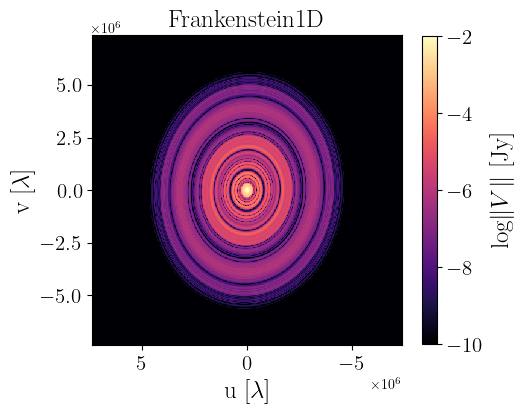

In [37]:
plt.figure(figsize = (5, 5))
plt.pcolormesh( u_f2d, v_f2d,
            np.log(np.abs(vis_f1d_2d.reshape(N, N))),
            cmap="magma",
            vmin=-10, vmax=-2)
zoom =1.5
plt.xlabel(r'u [$\lambda$]', size=18)
plt.ylabel(r'v [$\lambda$]', size=18)
plt.title("Frankenstein1D", size=18)
cmap = plt.colorbar(shrink=0.8)
cmap.set_label(r'log$\|V\|$ [Jy]', size=18)
cmap.ax.tick_params(labelsize=15)
plt.xlim(u_f2d.max()/zoom, u_f2d.min()/zoom)
plt.ylim(v_f2d.min()/zoom, v_f2d.max()/zoom)
plt.tick_params(axis='both', labelsize=15)
plt.gca().set_aspect(1)
plt.show()

In [38]:
from frank.utilities import sweep_profile
from frank.geometry import SourceGeometry
geom = SourceGeometry(inc= inc, PA= pa, dRA= dra, dDec= ddec)
I_f1d_2d, r_max, r_min = sweep_profile(sol.r, sol.mean, project= True, phase_shift = False, geom = geom, xmax = Rmax, ymax = Rmax, dr = (sol.r[1]- sol.r[0]))

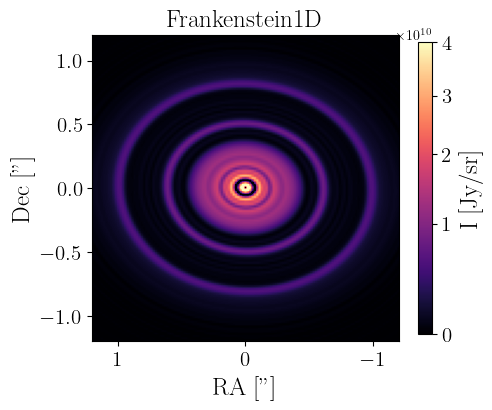

In [39]:
import matplotlib.patches as patches
from matplotlib.ticker import FuncFormatter
from matplotlib import colors

plt.figure(figsize=(5,5))
norm = colors.PowerNorm(gamma=0.7, vmin=0, vmax = 4e10)
ax = plt.gca()

im = ax.imshow(
    I_f1d_2d,
    extent=[Rmax, -Rmax, Rmax, -Rmax],
    aspect='equal',
    cmap='magma',
    norm=norm,
)


ax.set_xlabel('RA ["]', size=18)
ax.set_ylabel('Dec ["]', size=18)
ax.set_xlim(Rmax/3, -Rmax/3)
ax.set_ylim(Rmax/3, -Rmax/3)
ax.set_title(r'Frankenstein1D', size=18)
plt.tick_params(axis='both', labelsize=15)

cbar = plt.colorbar(im, ax=ax, shrink=0.65)
cbar.set_label( 'I [Jy/sr]', size=18)
cbar.ax.tick_params(labelsize=15)
cbar.update_ticks()
ax.grid(False)


plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## CLEAN MODEL

In [40]:
dir_  = "../../data/uvtable_model/"
data_file = dir_ +"CLEAN_model_AS209_continuum.npz"

# Load data
file = np.load(data_file)
u_c, v_c, Re_c, Im_c, Weights_c = file['u'], file['v'], file['Re'], file['Im'], file['w']
Vis_c = Re_c + Im_c*1j

In [41]:
# clean model
u_model_c = u_c
v_model_c = v_c
vis_model_c = Vis_c
weights_model_c = Weights_c

In [42]:
uvtable_clean = {'u': u_model_c, 'v': v_model_c, 'vis': vis_model_c, 'weights': weights_model_c}

In [43]:
Qmax_c = np.hypot(u_model_c, v_model_c).max()
Qmin_c = np.hypot(u_model_c, v_model_c).min()
print(f"-> q_min clean model: {Qmin_c}, q_max clean model: {Qmax_c}")

-> q_min clean model: 11458.93439803405, q_max clean model: 8857254.46918468


## Vis space


## 1D
* We use the full uvtable to make the profile.
* There is no convolution here!


In [44]:
u_input = uvtable['u']
v_input = uvtable['v']
vis_input = uvtable['vis']
weights_input = uvtable['weights']

min_input = np.hypot(u_input, v_input).min()

In [45]:
f2d = frank2d
geom = geom_f2d

# phase_shift
# is necessary to be done in the East of North convention.
vis_input = geom.apply_phase_shift(-u_input, -v_input, vis_input)
vis_model_c = geom.apply_phase_shift(-u_model_c, -v_model_c, vis_model_c)
    
# deproject
u_input_d, v_input_d, _ = geom.deproject(u_input, v_input)
u_model_c_d, v_model_c_d, _ = geom.deproject(u_model_c, v_model_c)
         

* Compare only where we have binned data input

In [46]:
# collocation points for the plot.
baselines_input_d = np.hypot(u_input_d, v_input_d)         
grid = np.logspace(np.log10(min(baselines_input_d.min(), baselines_input_d[0])),
                            np.log10(max(baselines_input_d.max(), baselines_input_d[-1])),
                            10**4)

bin_widths = [1e3, 1e4, 5e4, 1e5]

In [47]:
binned_vis0 = UVDataBinner(baselines_input_d, vis_input, weights_input , bin_widths[0])

In [48]:
bin_widths[0]

1000.0

In [66]:
binned_vis1 = UVDataBinner(baselines_input_d, vis_input, weights_input, bin_widths[1])
binned_vis2 = UVDataBinner(baselines_input_d, vis_input, weights_input, bin_widths[2])
binned_vis3 = UVDataBinner(baselines_input_d, vis_input, weights_input, bin_widths[3])

In [68]:
binning = binned_vis1
binning_data = binning.V
binning_err = binning.error
q_input_d = binning.uv.data # -> deprojected!
q_input_d = np.sort(q_input_d)
edges_input_d = edges(q_input_d)   

In [69]:
vis_models_1d_f2d = []

for f2d in frank_objects:
    # f2d model
    u_model_1d_f2d = f2d.u
    v_model_1d_f2d = f2d.v

    u_model_f2d = f2d.u_grid
    v_model_f2d = f2d.v_grid
    vis_model_f2d = f2d.visibility_model

    vis_model_f2d = geom_f2d.apply_phase_shift(-u_model_f2d, -v_model_f2d, vis_model_f2d)
    u_model_f2d_d, v_model_f2d_d, _ = geom_f2d.deproject(u_model_f2d, v_model_f2d)
    u_model_1d_f2d_d, v_model_1d_f2d_d, _ = geom_f2d.deproject(u_model_1d_f2d, v_model_1d_f2d)


    _, vis_model_1d_f2d = get_profile(u_model_f2d_d, v_model_f2d_d, vis_model_f2d,
                                                    bins = edges_input_d,
                                                    weighted = True, weights = np.ones_like(f2d.gridded_data['weights']))
    vis_models_1d_f2d.append(vis_model_1d_f2d)
                                

In [71]:

_, vis_model_1d_c = get_profile(u_model_c_d, v_model_c_d, vis_model_c,
                                            bins = edges_input_d,
                                            weighted = True, weights = np.ones_like(weights_model_c))

In [72]:
vis_model_f1d = f1d.predict_deprojected(q = q_input_d)

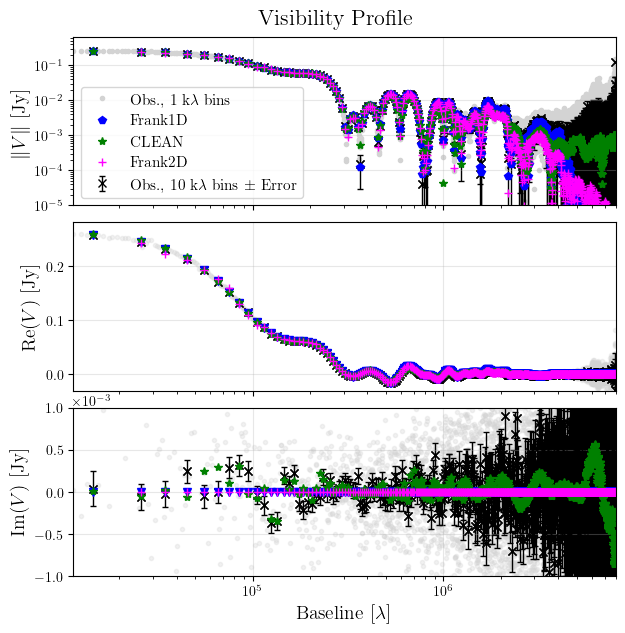

In [73]:
import matplotlib.pyplot as plt
import numpy as np

# Creamos una figura con 3 subplots verticales compartiendo el eje X
fig, ax = plt.subplots(3, 1, figsize=(7, 7), sharex=True)

# Ajuste de espacio entre subplots
plt.subplots_adjust(hspace=0.1) 

# =============================================================================
# 1. AMPLITUD (|V|) - Primer Subplot (ax[0])
# =============================================================================

# Raw visibilities
ax[0].plot(binned_vis0.uv, np.abs(binned_vis0.V), c='lightgray', alpha=1, zorder=0,
           marker='.', ls='None', 
           label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[0]/1e3))
ax[0].plot(q_input_d, np.abs(binning_data), c='black',
           marker='x', ls='None')

ax[0].errorbar(q_input_d, np.abs(binning_data), np.abs(binning_err), 
               color='black', fmt='x', capsize=2, linewidth=1, zorder=1, 
               label = r'Obs., {:.0f} k$\lambda$ bins $\pm$ Error'.format(bin_widths[1]/1e3))

# Modelos
ax[0].plot(q_input_d, np.abs(vis_model_f1d), color='blue', ls='None', marker='p', label=r'Frank1D')
ax[0].plot(q_input_d, np.abs(vis_model_1d_c), color='green', ls='None', marker='*', label=r'CLEAN')

# Frank2D loop
for i in range(len(vis_models_1d_f2d)):
    vis_model_1d_f2d_curr = vis_models_1d_f2d[i]
    # Rmax = frank_objects[i].Rmax # (Opcional si no lo usas en el label)
    ax[0].plot(q_input_d, np.abs(vis_model_1d_f2d_curr), marker='+', color='magenta', ls='None', label=f'Frank2D')
              

# Estética ax[0]
ax[0].set_ylabel(r'$\|V\|$ [Jy]', size=14)
ax[0].set_yscale('log')
ax[0].set_xscale('log')
ax[0].set_ylim(1e-5, None) 
ax[0].legend(fontsize=11, loc='lower left', frameon=True)
ax[0].grid(alpha=0.3)


# =============================================================================
# 2. PARTE REAL (Re(V)) - Segundo Subplot (ax[1])
# =============================================================================

# Raw visibilities
ax[1].plot(binned_vis0.uv, binned_vis0.V.real, c='lightgray', alpha=0.3, zorder=0, marker='.', ls='None')
ax[1].plot(q_input_d, binning_data.real, c='black', marker='x', ls='None')
ax[1].errorbar(q_input_d, binning_data.real, binning_err.real, 
               color='black', fmt='x', capsize=2, linewidth=1, zorder=1)

# Modelos
ax[1].plot(q_input_d, vis_model_f1d.real, color='blue', ls='None', marker='v')
ax[1].plot(q_input_d, vis_model_1d_c.real, color='green', ls='None', marker='*')

# Frank2D loop
for i in range(len(vis_models_1d_f2d)):
    ax[1].plot(q_input_d, vis_models_1d_f2d[i].real, marker='+', color='magenta', ls='None')

# Estética ax[1]
ax[1].set_ylabel(r'Re($V$) [Jy]', size=14)
ax[1].set_ylim(-0.03, 0.28) 
ax[1].grid(alpha=0.3)


# =============================================================================
# 3. PARTE IMAGINARIA (Im(V)) - Tercer Subplot (ax[2])
# =============================================================================

# Raw visibilities (.imag)
ax[2].plot(binned_vis0.uv, binned_vis0.V.imag, c='lightgray', alpha=0.3, zorder=0, marker='.', ls='None')
ax[2].plot(q_input_d, binning_data.imag, c='black', marker='x', ls='None')
ax[2].errorbar(q_input_d, binning_data.imag, binning_err.real, 
               color='black', fmt='x', capsize=2, linewidth=1, zorder=1)

# Modelos (.imag)
ax[2].plot(q_input_d, vis_model_f1d.imag, color='blue', ls='None', marker='v')
ax[2].plot(q_input_d, vis_model_1d_c.imag, color='green', ls='None', marker='*')

# Frank2D loop (.imag)
for i in range(len(vis_models_1d_f2d)):
    ax[2].plot(q_input_d, vis_models_1d_f2d[i].imag, marker='+', color='magenta', ls='None')

# Estética ax[2]
ax[2].set_ylabel(r'Im($V$) [Jy]', size=14)
ax[2].set_ylim(-0.001, 0.001) 
ax[2].set_xlabel(r'Baseline [$\lambda$]', size=14)
ax[2].set_xlim(min_input, 8e6)
ax[2].grid(alpha=0.3)

# --- AQUI ESTÁ EL CAMBIO ---
# 1. scilimits=(0,0) fuerza la notación científica para todos los números
# 2. axis='y' solo aplica al eje Y
ax[2].ticklabel_format(axis='y', style='sci', scilimits=(0,0))

# 3. Opcional: Esto hace que el multiplicador se vea como 'x10^3' en vez de '1e3'
ax[2].yaxis.get_major_formatter().set_useMathText(True)
# ---------------------------

# Título global
fig.suptitle('Visibility Profile', size=16, y=0.92)

plt.show()

#### Plot abs vis

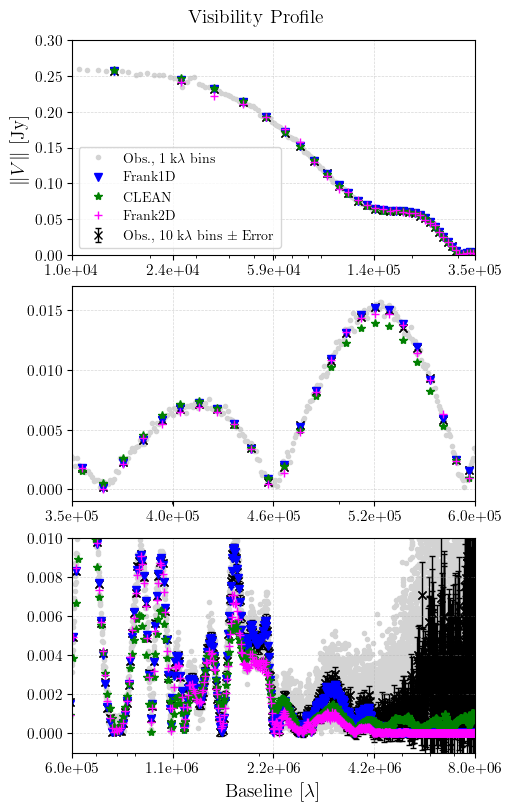

In [74]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

fig, axes = plt.subplots(3, 1, figsize=(5, 8), constrained_layout=True)
fig.suptitle(f'Visibility Profile', fontsize=14)

x_ranges = [
    [1e4, 3.5e5],
    [3.5e5, 6e5],
    [6e5, 8e6]
]

y_ranges = [
    [0, 0.3],
    [-1e-3, 0.017],
    [-0.001, 1e-2]
]

for i, (ax, x_lims, y_lims) in enumerate(zip(axes, x_ranges, y_ranges)):
    
    ax.plot(binned_vis0.uv, np.abs(binned_vis0.V), c='lightgray', zorder = 0, 
            marker='.', ls='None',
            label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[0]/1e3))
    ax.plot(q_input_d, np.abs(binning_data), c='black',
            marker='x', ls='None')
    ax.errorbar(q_input_d, np.abs(binning_data), binning_err.real, 
                color='black', fmt='x', capsize=2, linewidth=1, zorder=1, label='Obs., {:.0f} k$\lambda$ bins $\pm$ Error'.format(bin_widths[1]/1e3))

    ax.plot(q_input_d, np.abs(vis_model_f1d), color='blue', ls='None', marker='v', label='Frank1D')
    ax.plot(q_input_d, np.abs(vis_model_1d_c), color='green', ls='None', marker='*', label='CLEAN')

    for j in range(len(vis_models_1d_f2d)):
        vis_model_1d_f2d = vis_models_1d_f2d[j]
        Rmax = frank_objects[j].Rmax
        ax.plot(q_input_d, np.abs(vis_model_1d_f2d), color = 'magenta',  ls='None', marker='+', label= 'Frank2D') # label=f'frank2d: Rmax={Rmax:.2f} ["]')

    ax.set_xscale('log')
    ax.set_xlim(x_lims)

    if y_lims is not None:
        ax.set_ylim(y_lims)
        
    ax.grid(True, which='major', linestyle='--', linewidth=0.5, alpha=0.5)

    custom_ticks = np.geomspace(x_lims[0], x_lims[1], 5)
    ax.set_xticks(custom_ticks)
    
    ax.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.1e'))
    ax.xaxis.set_minor_formatter(ticker.NullFormatter())
    
    ax.tick_params(axis='both', rotation=0, labelsize=11)

    if i == 0:
        ax.legend(fontsize=10, loc='lower left', frameon=True)
        ax.set_ylabel(r'$\|V\|$ [Jy]', size=14)

axes[-1].set_xlabel(r'Baseline [$\lambda$]', fontsize=14)

plt.show()

##### Plot real vis

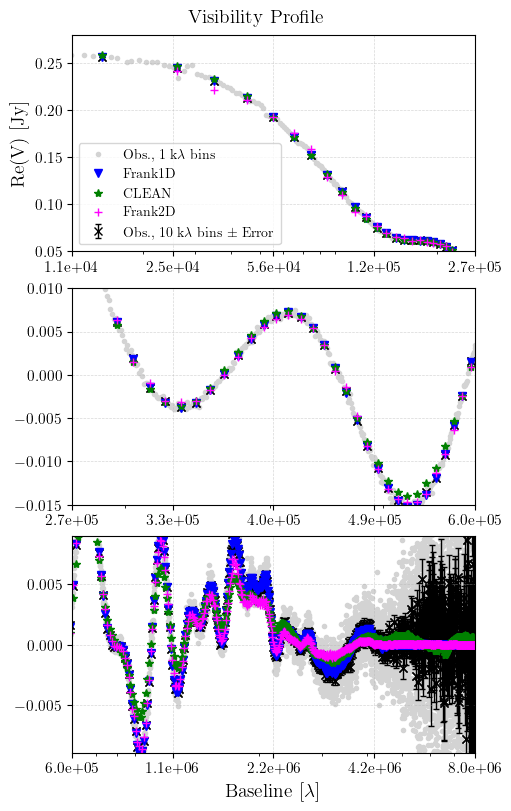

In [75]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

fig, axes = plt.subplots(3, 1, figsize=(5, 8), constrained_layout=True)
fig.suptitle(f'Visibility Profile', fontsize=14)

x_ranges = [
    [min_input, 2.7e5],
    [2.7e5, 6e5],
    [6e5, 8e6]
]

y_ranges = [
    [0.05, 0.28],
    [-0.015, 0.01],
    [-9e-3, 9e-3]
]

for i, (ax, x_lims, y_lims) in enumerate(zip(axes, x_ranges, y_ranges)):
    
    ax.plot(binned_vis0.uv, binned_vis0.V.real, c='lightgray', zorder = 0, 
            marker='.', ls='None',
            label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[0]/1e3))
    ax.plot(q_input_d, binning_data.real, c='black',
            marker='x', ls='None')
    ax.errorbar(q_input_d, binning_data.real, binning_err.real, 
                color='black', fmt='x', capsize=2, linewidth=1, zorder=1,
                label='Obs., {:.0f} k$\lambda$ bins $\pm$ Error'.format(bin_widths[1]/1e3))

    ax.plot(q_input_d, vis_model_f1d.real, color='blue', ls='None', marker='v', label='Frank1D')
    ax.plot(q_input_d, vis_model_1d_c.real, color='green', ls='None', marker='*', label='CLEAN')
    
    for j in range(len(vis_models_1d_f2d)):
        vis_model_1d_f2d = vis_models_1d_f2d[j]
        Rmax = frank_objects[j].Rmax
        ax.plot(q_input_d, vis_model_1d_f2d.real, color = 'magenta', ls='None', marker='+', label = 'Frank2D')
        # label=f'frank2d: Rmax={Rmax:.2f} ["]')

    ax.set_xscale('log')
    ax.set_xlim(x_lims)
    
    if y_lims is not None:
        ax.set_ylim(y_lims)
        
    ax.grid(True, which='major', linestyle='--', linewidth=0.5, alpha=0.5)

    custom_ticks = np.geomspace(x_lims[0], x_lims[1], 5)
    ax.set_xticks(custom_ticks)
    
    ax.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.1e'))
    ax.xaxis.set_minor_formatter(ticker.NullFormatter())
    
    ax.tick_params(axis='both', rotation=0, labelsize=11)

    if i == 0:
        ax.legend(fontsize=10, loc='lower left', frameon=True)
        ax.set_ylabel('Re(V) [Jy]', size=14)

axes[-1].set_xlabel(r'Baseline [$\lambda$]', fontsize=14)

plt.show()

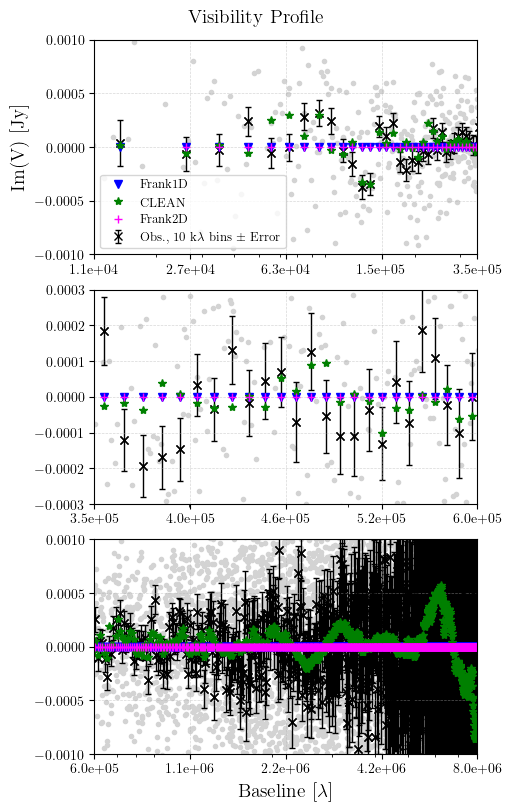

In [77]:
import matplotlib.ticker as ticker

fig, axes = plt.subplots(3, 1, figsize=(5, 8), constrained_layout=True)
fig.suptitle(f'Visibility Profile', fontsize=14)

x_ranges = [
    [min_input , 3.5e5],
    [3.5e5, 6e5],
    [6e5, 8e6]
]

y_ranges = [
    [-1e-3, 1e-3],
    [-3e-4, 3e-4],
    [-1e-3, 1e-3]
]

for i, (ax, x_lims, y_lims) in enumerate(zip(axes, x_ranges, y_ranges)):

    ax.plot(binned_vis0.uv, binned_vis0.V.imag, c='lightgray', zorder = 0, 
            marker='.', ls='None')
            #label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[1]/1e3))
    ax.plot(q_input_d, binning_data.imag, c='black',
            marker='x', ls='None') #, label='Obs. data')
    ax.errorbar(q_input_d, binning_data.imag, binning_err.real, 
                color='black', fmt='x', capsize=2, linewidth=1, zorder=1,
                label='Obs., {:.0f} k$\lambda$ bins $\pm$ Error'.format(bin_widths[1]/1e3))

    ax.plot(q_input_d, vis_model_f1d.imag, color='blue', ls='None', marker='v', label='Frank1D')
    ax.plot(q_input_d, vis_model_1d_c.imag, color='green', ls='None', marker='*', label='CLEAN')
    
    for j in range(len(vis_models_1d_f2d)):
        vis_model_1d_f2d = vis_models_1d_f2d[j]
        Rmax = frank_objects[j].Rmax
        ax.plot(q_input_d, vis_model_1d_f2d.imag, ls='None', marker='+', color = 'magenta', label = 'Frank2D')

    ax.set_xscale('log')
    ax.set_xlim(x_lims)
    
    if y_lims is not None:
        ax.set_ylim(y_lims)
        
    ax.grid(True, which='major', linestyle='--', linewidth=0.5, alpha=0.5)

    custom_ticks = np.geomspace(x_lims[0], x_lims[1], 5)
    ax.set_xticks(custom_ticks)
    
    ax.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.1e'))
    ax.xaxis.set_minor_formatter(ticker.NullFormatter())
    
    ax.tick_params(axis='x', rotation=0)

    if i == 0:
        ax.legend(fontsize=9, loc='best', frameon=True)
        ax.set_ylabel('Im(V) [Jy]', size=14)

axes[-1].set_xlabel(r'Baseline [$\lambda$]', fontsize=14)

plt.show()

#### Calculate the residuals

In [78]:
ground_sigma = binned_vis1.error
ground = binned_vis1.V

In [79]:
residual_clean_data = np.abs(ground - vis_model_1d_c) / ground_sigma.data.real
residual_f1d_data  =  np.abs(ground -vis_model_f1d) / ground_sigma.data.real

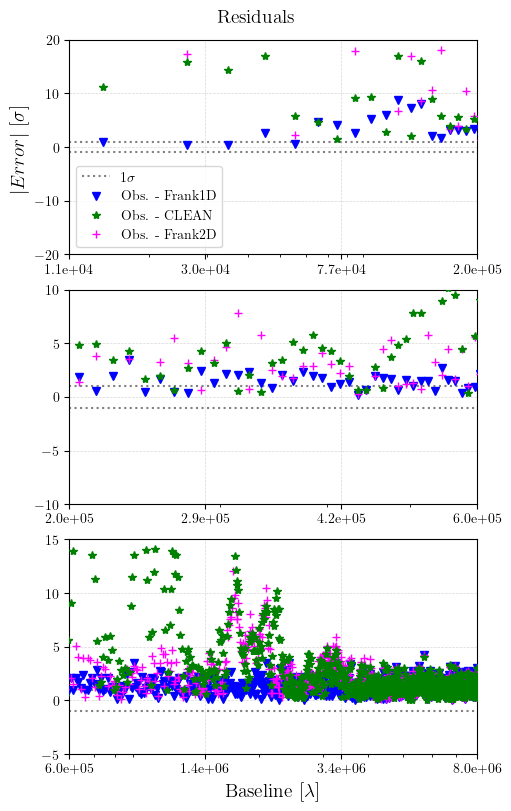

In [80]:
fig, axes = plt.subplots(3, 1, figsize=(5, 8), constrained_layout=True)
fig.suptitle('Residuals', fontsize=14)

x_ranges = [
    [min_input, 2e5],
    [2e5, 6e5],
    [6e5, 8e6]
]

y_ranges = [
    [-20, 20],
    [-10, 10],
    [-5, 15]
]

for i, (ax, x_lims, y_lims) in enumerate(zip(axes, x_ranges, y_ranges)):
    
    ax.axhline(1, color='gray', ls=':', label=r'1$\sigma$')
    ax.axhline(-1, color='gray', ls=':')
    
    ax.plot(q_input_d, residual_f1d_data, color='blue', ls='None',
            marker='v', zorder=9, label=r'Obs. - Frank1D')

    ax.plot(q_input_d, residual_clean_data, color='green', ls='None', 
            marker='*', zorder=10, label=r'Obs. - CLEAN')
    
    for j in range(len(vis_models_1d_f2d)):
        vis_model_1d_f2d = vis_models_1d_f2d[j]
        residual_f2d_data =  np.abs(ground - vis_model_1d_f2d) / ground_sigma.data.real
        ax.plot(q_input_d, np.abs(residual_f2d_data), ls='None',
                marker='+', zorder=9, label=f'Obs. - Frank2D', color = 'magenta')

    ax.set_xscale('log')
    ax.set_xlim(x_lims)
    
    if y_lims is not None:
        ax.set_ylim(y_lims)
    ax.grid(True, which='major', linestyle='--', linewidth=0.5, alpha=0.5)

    custom_ticks = np.geomspace(x_lims[0], x_lims[1], 4)
    ax.set_xticks(custom_ticks)
    ax.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.1e'))
    ax.xaxis.set_minor_formatter(ticker.NullFormatter())
    ax.tick_params(axis='x', rotation=0)

    if i == 0:
        ax.legend(fontsize=10, loc='best')
        ax.set_ylabel(r'$|Error|$ [$\sigma$]', size=14)

axes[-1].set_xlabel(r'Baseline [$\lambda$]', fontsize=14)

plt.show()

In [81]:
residual_clean_data_re = (ground.real - vis_model_1d_c.real) / ground_sigma.data.real
residual_f1d_data_re  =  (ground.real - vis_model_f1d.real) / ground_sigma.data.real

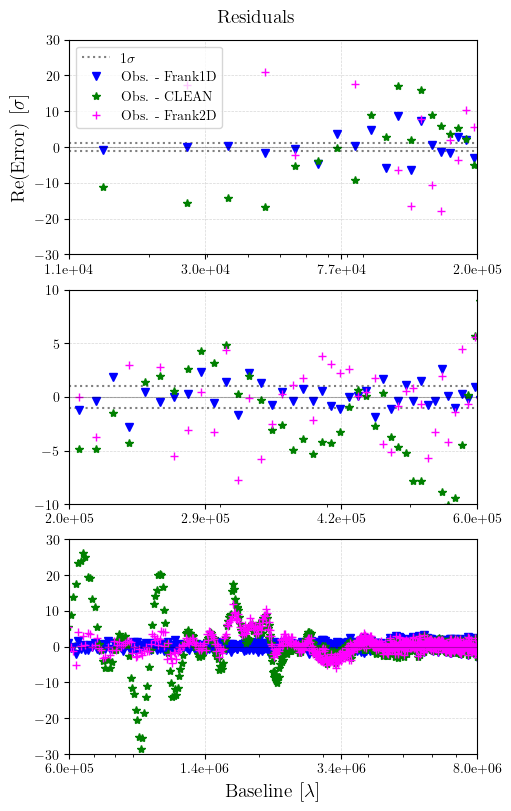

In [82]:
fig, axes = plt.subplots(3, 1, figsize=(5, 8), constrained_layout=True)
fig.suptitle('Residuals', fontsize=14)

x_ranges = [
    [min_input, 2e5],
    [2e5, 6e5],
    [6e5, 8e6]
]

y_ranges = [
    [-30, 30],
    [-10, 10],
    [-30, 30]
]

for i, (ax, x_lims, y_lims) in enumerate(zip(axes, x_ranges, y_ranges)):

    ax.axhline(1, color='gray', ls=':', label=r'1$\sigma$')
    ax.axhline(-1, color='gray', ls=':')

    ax.plot(q_input_d, residual_f1d_data_re, color='blue', ls='None',
            marker='v', label=r'Obs. - Frank1D')
    
    ax.plot(q_input_d, residual_clean_data_re, color='green', ls='None', 
            marker='*', label=r'Obs. - CLEAN')
    for j in range(len(vis_models_1d_f2d)):
        vis_model_1d_f2d = vis_models_1d_f2d[j]
        residual_f2d_data_re = ground.real - vis_model_1d_f2d.real
        residual_f2d_data_re = residual_f2d_data_re / ground_sigma.data.real
        ax.plot(q_input_d, residual_f2d_data_re, ls='None',
                marker='+', label=f'Obs. - Frank2D', color = 'magenta')

    ax.axhline(0, color='black', alpha=0.3, linewidth=0.8)

    ax.set_xscale('log')
    ax.set_xlim(x_lims)
    
    if y_lims is not None:
        ax.set_ylim(y_lims)

    ax.grid(True, which='major', linestyle='--', linewidth=0.5, alpha=0.5)

    custom_ticks = np.geomspace(x_lims[0], x_lims[1], 4)
    ax.set_xticks(custom_ticks)
    ax.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.1e'))
    ax.xaxis.set_minor_formatter(ticker.NullFormatter())
    
    ax.tick_params(axis='x', rotation=0)

    if i == 0:
        ax.legend(fontsize=10, loc='best', frameon=True)
        ax.set_ylabel(r'Re(Error) [$\sigma$]', size=14)

axes[-1].set_xlabel(r'Baseline [$\lambda$]', fontsize=14)

plt.show()

In [83]:
residual_clean_data_imag = (ground.imag - vis_model_1d_c.imag) / ground_sigma.data.imag
residual_f1d_data_imag  =  (ground.imag - vis_model_f1d.imag) / ground_sigma.data.imag

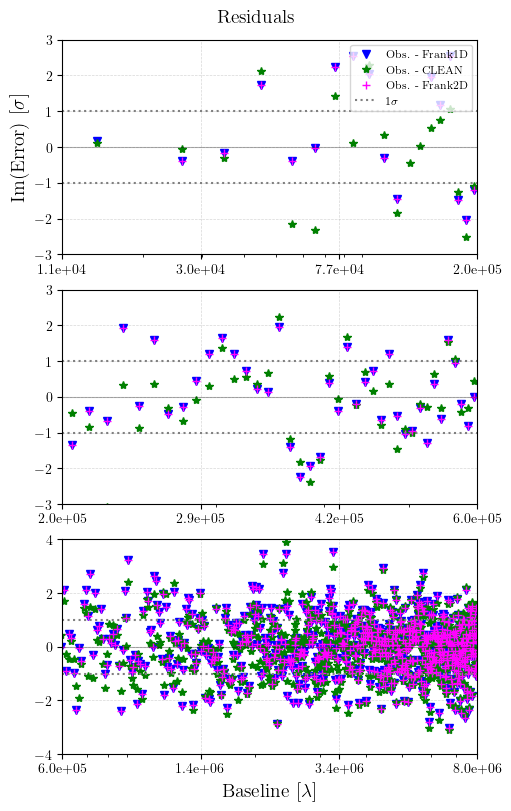

In [86]:
fig, axes = plt.subplots(3, 1, figsize=(5, 8), constrained_layout=True)
fig.suptitle('Residuals', fontsize=14)

x_ranges = [
    [min_input, 2e5],
    [2e5, 6e5],
    [6e5, 8e6]
]

y_ranges = [
    [-3, 3],
    [-3, 3],
    [-4, 4]
]

for i, (ax, x_lims, y_lims) in enumerate(zip(axes, x_ranges, y_ranges)):
    
    ax.plot(q_input_d, residual_f1d_data_imag, color='blue', ls='None',
            marker='v', label=r'Obs. - Frank1D')
    
    ax.plot(q_input_d, residual_clean_data_imag, color='green', ls='None', 
            marker='*', label=r'Obs. - CLEAN')

    for j in range(len(vis_models_1d_f2d)):
        vis_model_1d_f2d = vis_models_1d_f2d[j]
        residual_f2d_data_sigma_imag = (ground.imag - vis_model_1d_f2d.imag)
        residual_f2d_data_sigma_imag = residual_f2d_data_sigma_imag/ground_sigma.data.imag
        ax.plot(q_input_d, residual_f2d_data_sigma_imag, ls='None', 
            marker='+', label=r'Obs. - Frank2D', color = 'magenta')
        

    ax.axhline(1, color='gray', ls=':', label=r'1$\sigma$')
    ax.axhline(-1, color='gray', ls=':')
    ax.axhline(0, color='black', alpha=0.3, linewidth=0.8)

    ax.set_xscale('log')
    ax.set_xlim(x_lims)
    
    if y_lims is not None:
        ax.set_ylim(y_lims)

    ax.grid(True, which='major', linestyle='--', linewidth=0.5, alpha=0.5)

    custom_ticks = np.geomspace(x_lims[0], x_lims[1], 4)
    ax.set_xticks(custom_ticks)
    ax.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.1e'))
    ax.xaxis.set_minor_formatter(ticker.NullFormatter())
    
    ax.tick_params(axis='x', rotation=0)

    if i == 0:
        ax.legend(fontsize=8, loc='upper right', frameon=True)
        ax.set_ylabel(r'Im(Error) [$\sigma$]', size=14)

axes[-1].set_xlabel(r'Baseline [$\lambda$]', fontsize=14)

plt.show()

In [85]:
import numpy as np

def calculate_final_metrics(ground, model, sigma):
    """
    Calcula el error total considerando la naturaleza compleja de las visibilidades.
    
    ground : Masked Array complejo (Datos observados)
    model  : Array complejo (Tu modelo CLEAN o Frank)
    sigma  : Masked Array complejo (Solo usaremos la parte .real)
    """
    
    # 1. Definir el Sigma correcto (solo parte Real, como discutimos)
    # Usamos np.ma para respetar la máscara de los datos inválidos
    sigma_eff = sigma.real 
    
    # 2. Calcular el Vector Diferencia (Vectorial)
    # Esto calcula la distancia en el plano complejo: |V_obs - V_model|
    # Equivale a sqrt((Re_obs - Re_mod)^2 + (Im_obs - Im_mod)^2)
    diff_vector = ground - model
    diff_magnitude = np.abs(diff_vector)
    
    # 3. Calcular Chi-Cuadrado Total
    # (Distancia / Sigma)^2
    # Al elevar al cuadrado la magnitud, estamos sumando implícitamente:
    # (Error_Real/Sigma)^2 + (Error_Imag/Sigma)^2
    squared_residuals = (diff_magnitude / sigma_eff) ** 2
    
    chi2_total = np.ma.sum(squared_residuals)
    
    # 4. Calcular Grados de Libertad (N_obs)
    # Cada visibilidad cuenta por 2 (tiene parte Real y parte Imaginaria independientes)
    # np.ma.count cuenta solo los elementos NO enmascarados
    n_points = np.ma.count(ground)
    degrees_of_freedom = n_points * 2 
    
    # 5. Chi-Cuadrado Reducido
    chi2_reduced = chi2_total / degrees_of_freedom
    
    # EXTRA: Weighted RMSE (Error cuadrático medio ponderado)
    # Te dice el error promedio en unidades de sigma
    wrmse = np.sqrt(chi2_reduced)
    
    return {
        "Chi2 Reduced": chi2_reduced,
        "WRMSE (Sigmas)": wrmse,
        "Total Points Used": degrees_of_freedom
    }

# --- USO ---
metrics_clean = calculate_final_metrics(ground, vis_model_1d_c, ground_sigma)
metrics_frank2d = calculate_final_metrics(ground, vis_model_1d_f2d, ground_sigma)
metrics_frank1d = calculate_final_metrics(ground, vis_model_f1d, ground_sigma)

print("CLEAN:", metrics_clean)
print("FRANK:", metrics_frank2d)
print("FRANK1D:", metrics_frank1d)

CLEAN: {'Chi2 Reduced': 12.858149107567783, 'WRMSE (Sigmas)': 3.585826140175759, 'Total Points Used': 1598}
FRANK: {'Chi2 Reduced': 12.533759577698063, 'WRMSE (Sigmas)': 3.540305011958442, 'Total Points Used': 1598}
FRANK1D: {'Chi2 Reduced': 1.2597350921427057, 'WRMSE (Sigmas)': 1.122379210491136, 'Total Points Used': 1598}
